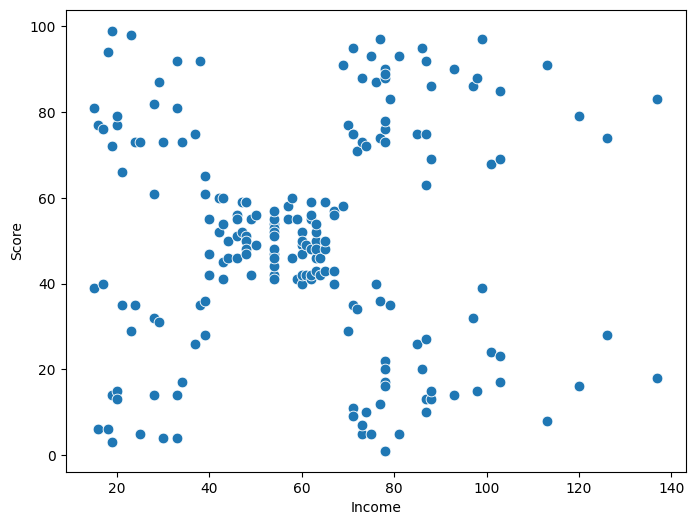

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('../datasets/unsupervised/Mall_Customers.csv')
df.head()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='Annual Income',y='Spending Score', s=60)
plt.xlabel('Income')
plt.ylabel('Score')
plt.show()
#쇼핑몰 고객 데이터에서 연 소득과 소비 점수의 관계를 점 그래프로 시각화한 코드

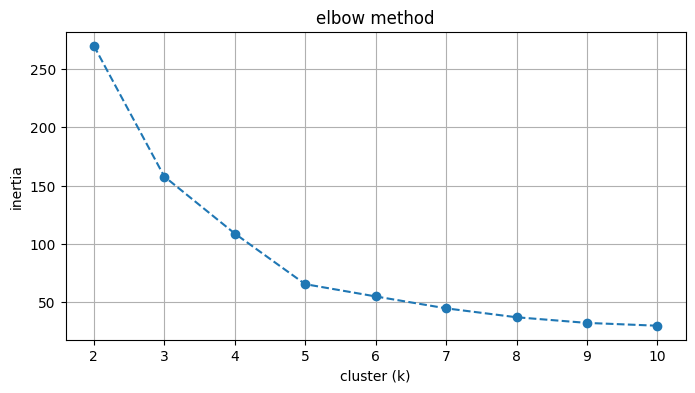

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
x = df[['Annual Income','Spending Score']].values
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
inertias = []
k_range = range(2,11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    kmeans.fit(x_scaled)
    inertias.append(kmeans.inertia_)
plt.figure(figsize=(8,4))
plt.plot(k_range,inertias, marker='o', linestyle='--')
plt.title('elbow method')
plt.xlabel('cluster (k)')
plt.ylabel('inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()


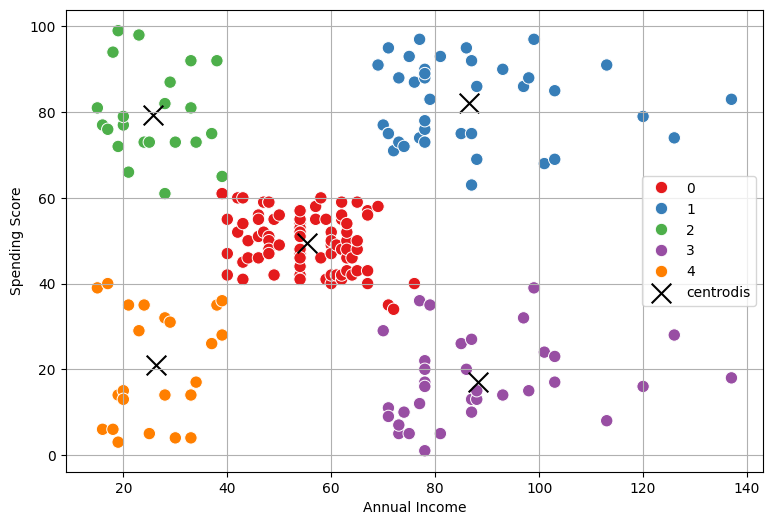

In [13]:
model = KMeans(n_clusters=5, random_state=42, n_init=10)
model_labels = model.fit_predict(x_scaled)
df['KMeans_Cluster'] = model_labels

plt.figure(figsize=(9,6))
sns.scatterplot(data=df,x='Annual Income',y='Spending Score', hue='KMeans_Cluster', palette='Set1', s=80)
centrodis = scaler.inverse_transform(model.cluster_centers_)
plt.scatter(centrodis[:,0], centrodis[:,1], marker='x', s=200, c='black', label='centrodis')
plt.legend()
plt.grid(True)
plt.show()

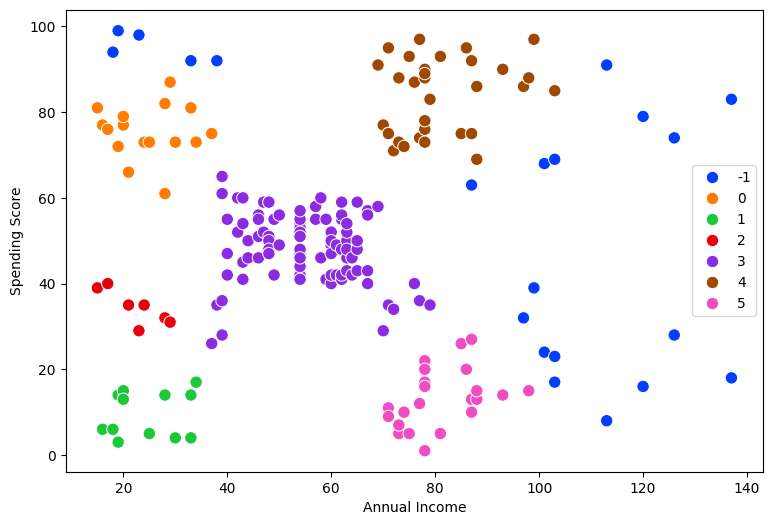

In [17]:
from sklearn.cluster import DBSCAN
#ebs(변경) min_samples(최소 데이터 개수)
dbscan = DBSCAN(eps=0.36, min_samples=5)
dbscan_labels = dbscan.fit_predict(x_scaled)
df['DBSCAN_Cluster'] = dbscan_labels
#레이블이 -1은 노이즈(outlier) 이상치로 분류됨
plt.figure(figsize=(9,6))
sns.scatterplot(data=df,x='Annual Income',y='Spending Score', hue='DBSCAN_Cluster', palette='bright', s=80)
plt.legend()
plt.show()